INSTRUCTIONS #1 &2 HANDLED BY MASON PETERS

In [14]:

# Step 1, simply importing everything I'd need for my section. 
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit #Taking the curve_fit function from scypy
from astropy.table import Table #This is to allow me to read the file. We've done an assignment like this before where we've read a file. 

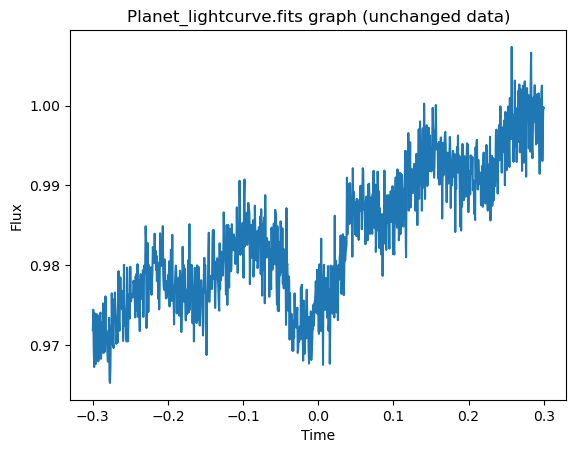

In [15]:
# Step 2, import the .fits file in, and plot out its original data without modifications or anything.

planetLightCurveFitsData = Table.read("Planet_lightcurve.fits", format = 'fits')

#print(planetLightcurveFitsData)
#print(planetLightcurveFitsData.colnames)
#  ^ Pretty sure I can comment these out now, they were here more for testing to just get an idea of what I was working with.
# Planet lightcurve has only two columns containing data- that being the time measured (in days), and flux. 


time = planetLightCurveFitsData['time [days]']
flux = planetLightCurveFitsData['flux']

plt.title("Planet_lightcurve.fits graph (unchanged data)")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.plot(time, flux) #Basically just plotting unchanged data from the file. In this case time and flux. 
plt.show()

In [16]:
# Step 3, here, Ithe bulk of what I am doing is finding the best fit for the function. I am using Scypy's curve fit function as 
# I felt that it was pretty intuitive. What I struggled on the most was actually finding a good initial guess. I do believe it's adequate, but
# it probably could be better. In step 4, I later plot everything, so basically step 3 is just doing some small calculations. 

# Basically the curve fit function's input. 
def curveFitFunctionInput(x, m, b, sinAmplitude, sinAFrequency, horizontalOffset):
    #curveFitFunctionInput will be later used in the curve_fit function from scypy. This is like the model function basically. 
    #Inputs:
    #x, the x input / changing value. 
    #m, the slope for the linear value (since this is both linear and oscillatory)
    #b, offset
    #sinAmplitude, the amplitude of the sine wave.
    #sinAFrequency, The angular frequency of the sine wave. 
    #horizontalOffSet, pretty self explanatory. Applies to the sine wave. 
    return ((m * x) + b) + (sinAmplitude * np.sin(sinAFrequency * x + horizontalOffset)) # Basically Y= mx+b PLUS sin(x) with the extra settings (like amplitude, frequency, etc.) 


sigma = 0.003
initial_guess = [0.0, 1.0, 0.05, 40.0, 0.0]

bestFitParams, uncertainty = curve_fit(curveFitFunctionInput, time, flux, p0=initial_guess, sigma=np.full(len(flux), sigma), absolute_sigma=True)
# bestFitParams as the name may imply essentially is a variable containing an array with data for what the "ideal fit" for the original data would be.
m = bestFitParams[0]
b = bestFitParams[1]
sinAmplitude = bestFitParams[2]
sinAFrequency = bestFitParams[3]
sinHorizontalOffset = bestFitParams[4]

# Parameter uncertainties
mError = np.sqrt(uncertainty[0][0])
bError = np.sqrt(uncertainty[1][1])
sinAmplitudeError = np.sqrt(uncertainty[2][2])
sinAFrequencyError = np.sqrt(uncertainty[3][3])
sinHorizontalOffsetError = np.sqrt(uncertainty[4][4])

# Here I'm just printing the uncertainty in my best fit parameters (as required for step 2.) + / - essentially is so I know there's something
# in-between both values. Everything has been rounded to 5 decimal values too. 
print("Best fit parameter uncertainties:")
print(f"m = {m:.5f} + / - {mError:.5f}")
print(f"b = {b:.5f} + / - {bError:.5f}")
print(f"sinAmplitude = {sinAmplitude:.5f} + / - {sinAmplitudeError:.5f}")
print(f"sinAFrequency = {sinAFrequency:.5f} + / - {sinAFrequencyError:.5f}")
print(f"sinHorizontalOffset = {sinHorizontalOffset:.5f} + / - {sinHorizontalOffsetError:.5f}")

Best fit parameter uncertainties:
m = 0.03929 + / - 0.00056
b = 0.98373 + / - 0.00010
sinAmplitude = 0.00272 + / - 0.00013
sinAFrequency = 50.52751 + / - 0.29774
sinHorizontalOffset = -0.21313 + / - 0.04999


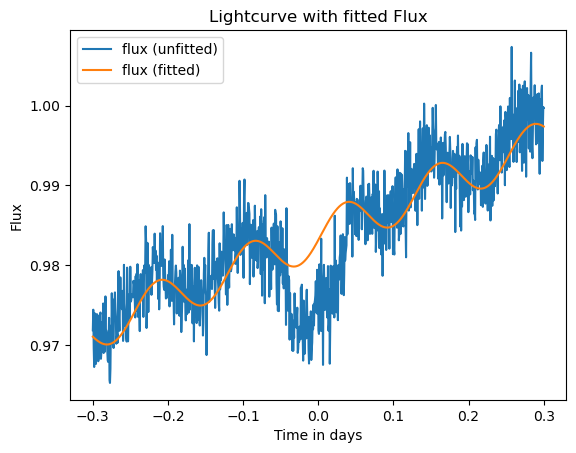

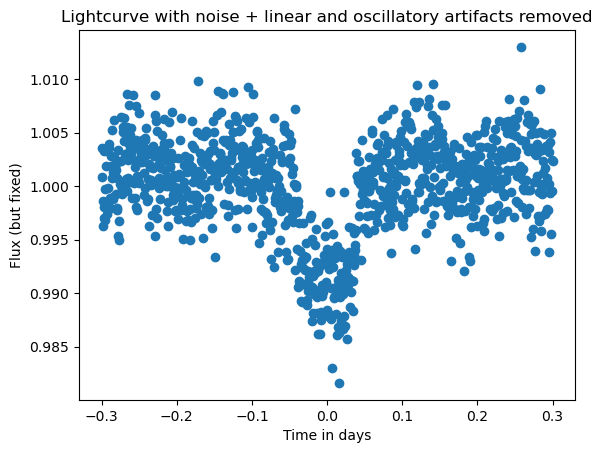

In [17]:
# Step 4, here I am graphing out the best fit for the planet_lightcurve.fits data. In the graph below you can see the orange line that
# was drawn. It's not perfect, but I do think that it syncs alright with the the data. I think its horizontal offset needs to be changed, but 
# I'm not sure. Either way, this section just plots that and then the lightcurve with the noise and other artifacts removed. 

fluxCurveFitted = curveFitFunctionInput(time, bestFitParams[0], bestFitParams[1], bestFitParams[2], bestFitParams[3], bestFitParams[4])

# These two graphs are plotted together that way the original data is below the line demonstrating the fit.
plt.title("Lightcurve with fitted Flux")
plt.xlabel("Time in days")
plt.ylabel("Flux")
plt.plot(time, flux, label = "flux (unfitted)")
plt.plot(time, fluxCurveFitted, label = "flux (fitted)")
plt.legend()
plt.savefig("planetLightCurveDataFitted.pdf")
plt.show()

fluxFixed = flux / fluxCurveFitted

plt.title("Lightcurve with noise + linear and oscillatory artifacts removed")
plt.xlabel("Time in days")
plt.ylabel("Flux (but fixed)")
plt.plot(time, fluxFixed, "o")
plt.savefig("planetLightCurveWithoutNoise&ArtifactsRemoved.pdf")
plt.show()

Yo! Mason here, I *think I have my section completed. Besides the initial guess being slightly goofy, I think its good. I know you need the fixed dataset to do your stuff, so the variable you can use to access everything is "fluxFixed". "time" is also there I guess in case it's needed.

Instructions 3-4 handled by Gabriel Campos

In [18]:
# Here I calculate the transit depth
# D = baseline flux (1.0) - minimum flux observed during transit
transit_depth = 1.0 - np.min(fluxFixed)

print(f"Estimated Transit Depth: {transit_depth:.5f} (relative flux)")

Estimated Transit Depth: 0.01838 (relative flux)


In [19]:
# I then identify indices where flux is significantly below the baseline (e.g., < 0.99)
transit_indices = np.where(fluxFixed < 0.99)[0]  # Get the actual indices array

# I now calculate length in days
# Duration = Time at the end of the transit - Time at the beginning
transit_start = time[transit_indices[0]]   # First transit point
transit_end = time[transit_indices[-1]]    # Last transit point
transit_length = transit_end - transit_start  # Now this is a single value

print(f"Estimated Transit Length: {transit_length:.5f} days")

Estimated Transit Length: 0.06847 days


In [20]:
# I finish up by calculating the radius
#R_star = 1.0 Solar Radii
R_star = 1.0

# Calculate R_planet = R_star * sqrt(D)
R_planet = R_star * np.sqrt(transit_depth)

print(f"Estimated Exoplanet Radius: {R_planet:.5f} Solar Radii")

Estimated Exoplanet Radius: 0.13558 Solar Radii


In [21]:
# With all that calculated, I now use error propagation to figure out the root mean squared uncertainty in the measurement of D and the transit time

# Relative errors added in quadrature
rel_err_data = 0.003 / np.min(flux)
# Assuming fit error is dominated by the baseline uncertainty 'bError'
rel_err_fit = bError / b 

sigma_D = transit_depth * np.sqrt(rel_err_data**2 + rel_err_fit**2)

# Propagating error for Transit Length
# The uncertainty in time at each edge is roughly the time resolution (cadence)
cadence = np.median(np.diff(time)) 
sigma_L = np.sqrt(cadence**2 + cadence**2)

print(f"RMS Uncertainty in D: {sigma_D:.5f}")
print(f"RMS Uncertainty in Length: {sigma_L:.5f} days")

RMS Uncertainty in D: 0.00006
RMS Uncertainty in Length: 0.00085 days
